### Подключаем пакет

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
# подмена агента для обращения к странице
url = 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'
pd.read_html(url, storage_options={"User-Agent": "Mozilla/5.0"})

[                                                   0  \
 0  Historical logarithmic graph of the DJIA from ...   
 1                                         Foundation   
 2                                           Operator   
 3                                          Exchanges   
 4                                     Trading symbol   
 5                                       Constituents   
 6                                               Type   
 7                                         Market cap   
 8                                   Weighting method   
 9                                            Website   
 
                                                    1  
 0  Historical logarithmic graph of the DJIA from ...  
 1  February 16, 1885; 141 years ago (as DJA)[1] M...  
 2                              S&P Dow Jones Indices  
 3                      New York Stock ExchangeNasdaq  
 4                                  ^DJI$INDU.DJIDJIA  
 5                                 

## Диверсификация портфеля
### Загрузка данных

In [3]:
# Импортируем перечень бумаг 
import pandas as pd
url= 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'
# методом тыка находим [1]
df = pd.read_html(url, storage_options={"User-Agent": "Mozilla/5.0"})[1]
df.head()


,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.85%
1,Alphabet,NASDAQ,GOOGL,Communication Services,2026-06-29,NaN,4.03%
2,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.88%
3,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.11%
4,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.74%


In [4]:
#Выгружаем тикера и названия компаний
names=df[['Symbol','Company']]
symbol=names['Symbol'].values
full_name=names['Company'].values
print(symbol)
print(full_name)

['MMM' 'GOOGL' 'AXP' 'AMGN' 'AMZN' 'AAPL' 'BA' 'CAT' 'CVX' 'CSCO' 'KO'
 'DIS' 'GS' 'HD' 'HON' 'IBM' 'JNJ' 'JPM' 'MCD' 'MRK' 'MSFT' 'NKE' 'NVDA'
 'PG' 'CRM' 'SHW' 'TRV' 'UNH' 'V' 'WMT']
['3M' 'Alphabet' 'American Express' 'Amgen' 'Amazon' 'Apple' 'Boeing'
 'Caterpillar' 'Chevron' 'Cisco' 'Coca-Cola' 'Disney' 'Goldman Sachs'
 'Home Depot' 'Honeywell Technologies' 'IBM' 'Johnson & Johnson'
 'JPMorgan Chase' "McDonald's" 'Merck' 'Microsoft' 'Nike' 'Nvidia'
 'Procter & Gamble' 'Salesforce' 'Sherwin-Williams'
 'Travelers Companies, Inc.' 'UnitedHealth Group' 'Visa' 'Walmart']


In [5]:
df.groupby('Exchange')['Symbol'].count()

Exchange
NASDAQ     9
NYSE      21
Name: Symbol, dtype: int64

In [6]:
# pip install yfinance     # установить
# pip install yfinance -U  # обновить

# ВАЖНО ПЕРЕЗАПУСТИТЬ ЯДРО

In [9]:
import yfinance as yf
import datetime

start = datetime.datetime(2020, 6, 1)
end = datetime.datetime(2021, 2, 28)

data = yf.download(list(symbol), start=start, end=end)['Close']
data

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01,77.906036,188.527084,123.552002,89.438416,151.389999,107.639267,173.360779,38.711876,71.525856,115.155014,...,62.384201,173.778732,90.882179,8.761646,100.766235,184.100967,95.968178,274.903778,186.094025,38.156071
2020-06-02,78.266685,185.876678,123.620499,91.583076,153.309998,110.158302,171.266983,39.205173,72.990433,115.135635,...,63.387852,175.755768,91.977806,8.780547,101.462372,188.731445,97.594765,275.245209,188.018616,38.149910
2020-06-03,78.697556,183.616730,123.919998,97.434708,173.160004,113.525925,172.014084,39.246979,74.909821,118.461227,...,64.344490,176.183456,95.054672,8.725081,101.866287,187.799011,100.645691,274.382568,188.506943,38.005245
2020-06-04,78.019806,183.517059,123.029999,98.488541,184.300003,115.196350,168.524445,39.180107,74.216072,119.925270,...,63.944595,173.864288,92.470833,8.726078,99.734947,181.793610,103.749390,267.849884,185.414139,37.586632
2020-06-05,80.241905,187.496811,124.150002,101.437469,205.429993,120.698914,170.922958,39.991131,77.707947,121.020882,...,64.501297,177.932388,93.776466,8.878870,101.694420,184.995422,109.341286,280.223328,191.130524,37.417339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-22,122.610466,196.368393,159.037003,127.218010,212.880005,198.494873,236.852356,38.950146,79.171524,185.923447,...,60.122543,224.539978,125.310722,14.298055,110.742859,224.846451,132.700531,297.966614,200.383698,42.712101
2021-02-23,122.474243,197.208237,159.725006,128.144409,212.119995,200.424667,231.632645,39.018723,80.169296,191.091202,...,59.809643,223.352722,124.815590,14.085161,111.565262,221.026184,134.010742,299.667236,204.029297,42.023441
2021-02-24,121.977959,195.112839,157.976501,130.904999,229.339996,202.509216,236.380524,39.215931,83.130493,191.498413,...,59.833691,224.578323,124.375458,14.440726,111.687729,216.406326,135.473572,302.122681,211.070419,41.322376


In [10]:
price = data

In [11]:
# дропнем колонки со слишком большим процентом пропусков
price = price.dropna( thresh = 0.91*len(price.index) , axis='columns')
price

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-01,77.906036,188.527084,123.552002,89.438416,151.389999,107.639267,173.360779,38.711876,71.525856,115.155014,...,62.384201,173.778732,90.882179,8.761646,100.766235,184.100967,95.968178,274.903778,186.094025,38.156071
2020-06-02,78.266685,185.876678,123.620499,91.583076,153.309998,110.158302,171.266983,39.205173,72.990433,115.135635,...,63.387852,175.755768,91.977806,8.780547,101.462372,188.731445,97.594765,275.245209,188.018616,38.149910
2020-06-03,78.697556,183.616730,123.919998,97.434708,173.160004,113.525925,172.014084,39.246979,74.909821,118.461227,...,64.344490,176.183456,95.054672,8.725081,101.866287,187.799011,100.645691,274.382568,188.506943,38.005245
2020-06-04,78.019806,183.517059,123.029999,98.488541,184.300003,115.196350,168.524445,39.180107,74.216072,119.925270,...,63.944595,173.864288,92.470833,8.726078,99.734947,181.793610,103.749390,267.849884,185.414139,37.586632
2020-06-05,80.241905,187.496811,124.150002,101.437469,205.429993,120.698914,170.922958,39.991131,77.707947,121.020882,...,64.501297,177.932388,93.776466,8.878870,101.694420,184.995422,109.341286,280.223328,191.130524,37.417339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-22,122.610466,196.368393,159.037003,127.218010,212.880005,198.494873,236.852356,38.950146,79.171524,185.923447,...,60.122543,224.539978,125.310722,14.298055,110.742859,224.846451,132.700531,297.966614,200.383698,42.712101
2021-02-23,122.474243,197.208237,159.725006,128.144409,212.119995,200.424667,231.632645,39.018723,80.169296,191.091202,...,59.809643,223.352722,124.815590,14.085161,111.565262,221.026184,134.010742,299.667236,204.029297,42.023441
2021-02-24,121.977959,195.112839,157.976501,130.904999,229.339996,202.509216,236.380524,39.215931,83.130493,191.498413,...,59.833691,224.578323,124.375458,14.440726,111.687729,216.406326,135.473572,302.122681,211.070419,41.322376


In [12]:
result_corr = price.corr()
display(result_corr.head())
np.fill_diagonal(result_corr.values,0.)
result_corr.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,1.000000,0.107876,0.824848,0.669825,0.409271,0.815281,0.646796,-0.046019,0.052186,0.788305,...,0.288380,0.852626,0.848927,0.894699,0.675310,0.880277,0.682591,0.765092,0.663092,0.817032
AMGN,0.107876,1.000000,0.353200,-0.184146,-0.259941,-0.129822,0.087677,0.090566,-0.109943,-0.110707,...,0.279481,0.206503,-0.193939,0.041980,0.004618,-0.028536,-0.198645,-0.131912,0.012869,-0.034407
AMZN,0.824848,0.353200,1.000000,0.280924,0.059548,0.511226,0.695161,-0.196229,-0.232172,0.429968,...,0.306566,0.781824,0.544454,0.807361,0.728916,0.705333,0.325675,0.508275,0.475791,0.699664
AXP,0.669825,-0.184146,0.280924,1.000000,0.827452,0.903792,0.286675,0.352950,0.606095,0.924524,...,-0.037749,0.649046,0.807380,0.596920,0.193494,0.622617,0.911616,0.739448,0.735379,0.579203
BA,0.409271,-0.259941,0.059548,0.827452,1.000000,0.628049,-0.063643,0.576184,0.755801,0.753755,...,-0.072472,0.412543,0.553836,0.247684,-0.055135,0.333275,0.793063,0.580484,0.615638,0.352137


Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000000,0.107876,0.824848,0.669825,0.409271,0.815281,0.646796,-0.046019,0.052186,0.788305,...,0.288380,0.852626,0.848927,0.894699,0.675310,0.880277,0.682591,0.765092,0.663092,0.817032
AMGN,0.107876,0.000000,0.353200,-0.184146,-0.259941,-0.129822,0.087677,0.090566,-0.109943,-0.110707,...,0.279481,0.206503,-0.193939,0.041980,0.004618,-0.028536,-0.198645,-0.131912,0.012869,-0.034407
AMZN,0.824848,0.353200,0.000000,0.280924,0.059548,0.511226,0.695161,-0.196229,-0.232172,0.429968,...,0.306566,0.781824,0.544454,0.807361,0.728916,0.705333,0.325675,0.508275,0.475791,0.699664
AXP,0.669825,-0.184146,0.280924,0.000000,0.827452,0.903792,0.286675,0.352950,0.606095,0.924524,...,-0.037749,0.649046,0.807380,0.596920,0.193494,0.622617,0.911616,0.739448,0.735379,0.579203
BA,0.409271,-0.259941,0.059548,0.827452,0.000000,0.628049,-0.063643,0.576184,0.755801,0.753755,...,-0.072472,0.412543,0.553836,0.247684,-0.055135,0.333275,0.793063,0.580484,0.615638,0.352137


In [13]:
result=(abs(result_corr)>=0.8).astype(int)
#result=(result_corr>=0.9).astype(int)
result.head()

Ticker,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0,0,1,0,0,1,0,0,0,0,...,0,1,1,1,0,1,0,0,0,1
AMGN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AMZN,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
AXP,0,0,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
BA,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
import matplotlib.pyplot as plt
import networkx as nx

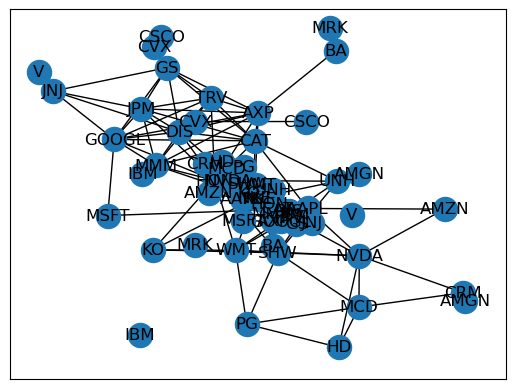

In [15]:
A=result.values
G=nx.from_numpy_array(A)
mapping=dict(zip(G.nodes(),result.index))

G1=nx.relabel_nodes(G,mapping)

nx.draw_networkx(G1)
nx.draw_networkx(G1,pos=nx.kamada_kawai_layout(G1))
plt.show()

In [16]:
clique=list(nx.find_cliques(G1))
print(clique)
max_clique=max(clique,key=len)
print()
print("максимальная ",max_clique)

[['V'], ['JNJ', 'GOOGL', 'DIS', 'GS', 'JPM'], ['CRM', 'NVDA', 'MCD'], ['CSCO', 'CVX'], ['MSFT', 'AAPL'], ['MSFT', 'GOOGL'], ['MCD', 'HD', 'NVDA'], ['MCD', 'HD', 'PG'], ['MCD', 'SHW', 'NVDA'], ['MCD', 'SHW', 'PG'], ['MRK'], ['PG', 'WMT', 'SHW'], ['IBM'], ['NVDA', 'AAPL', 'NKE', 'SHW', 'WMT'], ['NVDA', 'AAPL', 'AMZN'], ['AMGN'], ['BA', 'AXP'], ['HON', 'NKE', 'SHW', 'WMT', 'UNH'], ['HON', 'NKE', 'SHW', 'WMT', 'AAPL'], ['HON', 'NKE', 'SHW', 'WMT', 'KO'], ['HON', 'NKE', 'CAT', 'UNH'], ['HON', 'NKE', 'CAT', 'AAPL'], ['HON', 'NKE', 'CAT', 'AXP', 'MMM', 'DIS'], ['HON', 'TRV', 'AXP', 'MMM', 'DIS', 'JPM', 'CAT', 'GOOGL'], ['GS', 'AXP', 'TRV', 'DIS', 'JPM', 'CAT', 'GOOGL']]

максимальная  ['HON', 'TRV', 'AXP', 'MMM', 'DIS', 'JPM', 'CAT', 'GOOGL']


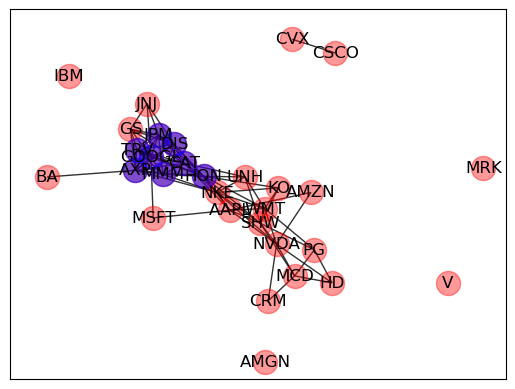

In [17]:
pos = nx.spring_layout(G1,dim=2,k=0.5)
nx.draw_networkx_nodes(G1,pos,node_color='r',alpha=0.4)
nx.draw_networkx_nodes(G1,pos,nodelist=max_clique,node_color='b',alpha=0.5)
nx.draw_networkx_edges(G1,pos,width=1.0,alpha=0.8)
nx.draw_networkx_labels(G1,pos)
plt.show()


In [18]:
# Имена бумаг в клике
max_clique_name=names.loc[names['Symbol'].isin(max_clique)]
display(max_clique_name)
# Только имена бумаг
print(max_clique_name['Company'].values)

,Symbol,Company
0,MMM,3M
1,GOOGL,Alphabet
2,AXP,American Express
7,CAT,Caterpillar
11,DIS,Disney
14,HON,Honeywell Technologies
17,JPM,JPMorgan Chase
26,TRV,"Travelers Companies, Inc."


['3M' 'Alphabet' 'American Express' 'Caterpillar' 'Disney'
 'Honeywell Technologies' 'JPMorgan Chase' 'Travelers Companies, Inc.']


In [19]:
no_max_clique_name=names.loc[~names['Symbol'].isin(max_clique)]
no_max_clique_name

,Symbol,Company
3,AMGN,Amgen
4,AMZN,Amazon
5,AAPL,Apple
6,BA,Boeing
8,CVX,Chevron
9,CSCO,Cisco
10,KO,Coca-Cola
12,GS,Goldman Sachs
13,HD,Home Depot
15,IBM,IBM


In [20]:
df=pd.DataFrame(price, columns=max_clique_name['Symbol'].values)
display(df.head(3))
display(df.shape)
display(df.describe())
df = df.pct_change().fillna(0).cumsum()
display(df.head())

,MMM,GOOGL,AXP,CAT,DIS,HON,JPM,TRV
Date,,,,,,,,
2020-06-01,105.279129,71.112923,89.438416,107.639267,115.155014,127.805267,83.783844,95.968178
2020-06-02,106.673119,71.481659,91.583076,110.158302,115.135635,129.702515,84.064278,97.594765
2020-06-03,109.088898,71.330002,97.434708,113.525925,118.461227,134.074036,88.601868,100.645691


(188, 8)

,MMM,GOOGL,AXP,CAT,DIS,HON,JPM,TRV
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,113.733400,81.723783,100.971780,144.604155,137.237800,156.584104,96.005389,111.670417
std,6.103375,9.520681,11.684284,23.597744,24.346947,22.261895,14.940378,11.868091
min,101.780647,67.528214,84.105331,107.639267,105.779335,120.837105,78.319626,95.812210
25%,109.116615,74.240812,90.444126,124.113760,118.686659,137.760002,84.379356,101.269829
50%,113.516571,78.539577,97.285347,140.771210,126.634655,150.302414,87.913078,106.393154
75%,118.782608,87.299889,110.990927,162.387264,165.320225,179.837975,105.748772,122.530609
max,128.556061,104.999947,130.904999,202.509216,191.498413,189.597000,133.675461,135.473572


,MMM,GOOGL,AXP,CAT,DIS,HON,JPM,TRV
Date,,,,,,,,
2020-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-06-02,0.013241,0.005185,0.023979,0.023403,-0.000168,0.014845,0.003347,0.016949
2020-06-03,0.035887,0.003064,0.087873,0.053973,0.028716,0.048549,0.057325,0.048210
2020-06-04,0.044200,-0.014272,0.098689,0.068687,0.041075,0.065243,0.078136,0.079048
2020-06-05,0.074098,0.003914,0.128631,0.116454,0.050210,0.100263,0.123138,0.132946


<Figure size 300x300 with 0 Axes>

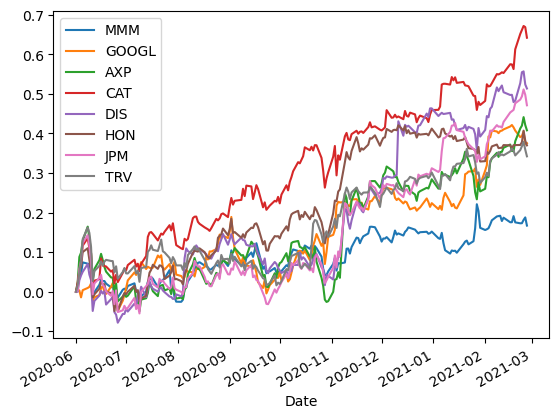

In [21]:
fig = plt.figure(figsize=(3, 3));
df.plot();
plt.show();

In [22]:
# pip install pyvis

In [25]:
from pyvis.network import Network
net = Network(notebook=True, cdn_resources='remote')
net.from_nx(G1)
net.show("example.html")

example.html


In [28]:
from pyvis.network import Network
net = Network(notebook=True, cdn_resources='remote')

colours = []

for node in G1.nodes: 
    if node in max_clique:
        net.add_node(node, color='red')  # меняем цвет для узлов в максимальной клике
    else:
        net.add_node(node)

for e in G1.edges:
    if e in nx.complete_graph(max_clique).edges:  # если ребро часть клики - меняем цвет
        color = 'red'
        width = 4
    else:
        color = 'black'
        width = 2
    net.add_edge(e[0], e[1], color=color, width=width)

net.edges
net.show("01.html")    

01.html
